# Granite Vision 3.3 — Referring Segmentation (with optional Bounding Box)

This notebook shows how to use **`ibm-granite/granite-vision-3.3-2b`** to produce a *referring segmentation* mask from an image + a short phrase (e.g., “dog on the left”), then (optionally) derive a **bounding box** from that mask.

### What to expect (important limitations)
- The model returns a segmentation mask on a **24×24 patch grid** (coarse). Fine edges and very small objects may look blocky.
- The processor may **resize and/or center-crop** images internally. If your input image is very wide/tall, the predicted mask can appear misaligned when you overlay it back onto the original.

### Recommended image shape for best overlays
For the most consistent results:
- Prefer **square (1:1)** images.
- Use at least **~384×384** resolution (larger is fine).
- If your images are not square, consider **padding to square** (letterbox) *before* inference so the model “sees” the whole frame.

You can still run non-square images, but expect more variability in mask alignment and prompt sensitivity.


In [ ]:
# If running in a fresh environment, install dependencies.
# NOTE: Installing PyTorch may require a platform-specific command.
# In Colab, this is usually enough; on other systems, follow https://pytorch.org/get-started/locally/
!pip -q install transformers torch pillow requests


The Granite Vision 3.3 model provides experimental support for **referring segmentation** (segment the region described by a phrase).

The model emits a Text4Seg-style `<seg> ... </seg>` block on a **24×24 patch grid**. In this notebook we:
1. Prompt the model with `seg: <your target>`
2. Parse the `<seg>` output into a 24×24 mask
3. Upsample the mask back to image resolution for visualization
4. (Optional) Convert the mask to a **bounding box**

**Tip on image shapes:** because the processor typically resizes and may crop/pad images, segmentation overlays tend to be most reliable on **square** images (1:1). If you see masks that look shifted or “don’t cover” the full frame, try padding/cropping your image to square before running inference.


## Imports

This cell imports the Python packages used throughout the notebook:

- **requests / PIL**: download + open images
- **torch**: run the model and upsample the mask
- **transformers**: load the Granite Vision model + processor

If you see `ModuleNotFoundError`, run the *Install dependencies* cell at the top first.

In [2]:
import re
import requests
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoProcessor, AutoModelForVision2Seq

/Users/shonda.adena.witherspoon/miniforge3/envs/granite-vision-test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the Granite Vision model

We load **`ibm-granite/granite-vision-3.3-2b`** and its paired `AutoProcessor`.

- `device` controls whether inference runs on **CPU** or **GPU**.
- The processor handles image preprocessing and chat template formatting.

Tip: if you have a CUDA GPU available, set `device = "cuda"` for faster inference.

In [2]:
device = "cpu"

model_path = "ibm-granite/granite-vision-3.3-2b"
processor = AutoProcessor.from_pretrained(model_path)
model = AutoModelForVision2Seq.from_pretrained(model_path).to(device)

/Users/shonda.adena.witherspoon/miniforge3/envs/granite-vision-test/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
Loading checkpoint shards: 100%|███████████████████████████████████████████████████████████████| 2/2 [00:12<00:00,  6.04s/it]


## Load an example image

This cell downloads a sample image from the web and opens it with PIL.

You can replace the URL with your own image, or load from disk (e.g., `Image.open('path/to/file.jpg')`).

In [3]:
image = Image.open(requests.get("http://farm2.staticflickr.com/1045/934293170_d1b2cc58ff_z.jpg", stream=True).raw)

# To load your local image instead, uncomment the following code below
#image_path = "PATH_TO_IMAGE"  # Change this to your image path
#image = Image.open(image_path)

## Preview the input image

Displays the loaded image so you can visually confirm the content and orientation before prompting the model.

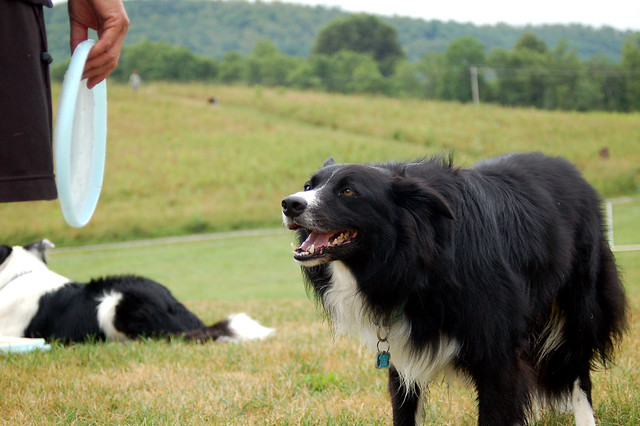

In [4]:
image

### Task prefix

Granite Vision uses a simple task prefix. For referring segmentation we start the prompt with:

- `seg: ...`

Everything after `seg:` should be the short description of what you want segmented (the *referring expression*).


## Choose the referring expression (the 'prompt')

Set `target` to the object/region you want segmented.

Best results usually come from short, concrete descriptions (e.g., *"dog on the left"*, *"red mug"*, *"person in blue shirt"*). If there are multiple similar objects, add a disambiguator like *left/right/front/back*.

In [5]:
target = 'dog laying on the left'

## Build the chat conversation

Granite Vision uses a chat-style input. This cell constructs the message list containing:

- the **image**
- the **task instruction** (segmentation)
- your **target** phrase

Downstream cells feed this conversation into the processor.

In [6]:
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": f"seg: Could you segment the '{target}' in the image? Respond with the segmentation mask"},
        ],
    },
]

## Tokenize / format inputs for the model

`apply_chat_template` converts the conversation into model-ready tensors.

This is also where the processor applies its image preprocessing (resize/crop/pad). The segmentation mask that comes back is aligned to the *processed* image space.

In [7]:
inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(device)


## Run inference

Generates the model output.

Notes:
- `torch.inference_mode()` disables gradients for speed.
- `autocast(bfloat16)` can improve performance on supported hardware. If you hit dtype issues on CPU, you can remove the autocast context.

In [8]:
with torch.autocast(device, dtype=torch.bfloat16), torch.inference_mode():
    output = model.generate(**inputs, max_new_tokens=8192)

## Decode the model output

Converts token IDs to text. For referring segmentation, the response includes a `<seg> ... </seg>` block that encodes a **24×24 patch mask**.

In [9]:
decoded_output = processor.decode(output[0], skip_special_tokens=True)

### Decoding → mask

The model’s response includes a `<seg>` block that encodes the segmentation as **run-length-like tokens** over a **24×24** grid.

In the next cells we parse that text into a numeric mask and then upsample it to the image size for display.


## Inspect raw model text

Prints the decoded output so you can debug failures (e.g., missing `<seg>` tags, truncated output, or unexpected formatting).

In [10]:
print(decoded_output)

<|system|>
A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions.
<|user|>

seg: Could you segment the 'dog laying on the left' in the image? Respond with the segmentation mask
<|assistant|>
Here is the segmentation map focusing on the dog laying on the left:
<seg>others *24
 others *24
 others *24
 others *24
 others *24
 others *24
 others *24
 others *24
 others *24
 others *24
 others *24
 others *24
 others *24
 others *1| dog laying on the left *1| others *22
 dog laying on the left *2| others *22
 dog laying on the left *3| others *21
 dog laying on the left *6| others *18
 dog laying on the left *7| others *17
 dog laying on the left *10| others *14
 others *24
 others *24
 others *24
 others *24
 others *24
</seg>


## Parse the `<seg>` block into a patch mask

This function extracts the Text4Seg-style mask from the model text.

It returns a flat list of length `patch_h * patch_w` (default **24×24 = 576**), where each entry is a label ID. We treat any non-zero label as foreground.

In [11]:
def extract_segmentation(
    text: str,
    labels: dict[str, int] | None = None,
    patch_h: int = 24,
    patch_w: int = 24,
) -> list[int] | None:
    """Extracts the segmentation part from a given text."""
    try:
        rows = (
            re.search(r"<seg>(.*?)</seg>", text, re.DOTALL).group(1).strip().split("\n")
        )
    except AttributeError:
        return None
    tokens = [token.split(" *") for row in rows for token in row.split("| ")]
    tokens = [x[0].strip() for x in tokens for _ in range(int(x[1]))]
    if not labels:
        labels = {"others": 0}

    mask = [labels.get(item, 1) for item in tokens]
    total_size = patch_h * patch_w
    if len(mask) < total_size:
        mask = mask + [mask[-1]] * (total_size - len(mask))
    elif len(mask) > total_size:
        mask = mask[:total_size]
    return mask

def prepare_mask(
    mask: list[int], patch_h: int, patch_w: int, size: tuple[int, int]
) -> torch.Tensor:
    mask: torch.Tensor = torch.as_tensor(mask).reshape((patch_h, patch_w))
    mask = mask.gt(0).to(dtype=torch.float32)
    mask = F.interpolate(
        mask[None, None],
        size=(size[1], size[0]),
        mode="nearest",
    ).squeeze()
    return mask


## Convert patch mask to full-resolution tensor

This cell:

1. Parses the segmentation block
2. Reshapes it to **24×24**
3. Upsamples it (nearest-neighbor) to match the displayed image resolution

The result is a `torch.Tensor` mask aligned to the image you plan to visualize.

In [12]:
mask = extract_segmentation(decoded_output)
mask = prepare_mask(mask, patch_h=24, patch_w=24, size=image.size)

## Create a PIL-friendly mask image

Converts the tensor mask into an 8-bit (`L`) PIL image so it can be displayed/saved easily.

In [13]:
pil_mask = Image.fromarray((mask.to(torch.uint8) * 255).numpy(), mode="L")

## Visualize the mask

This cell is a placeholder comment for visualization. The actual overlay happens in the next two cells.

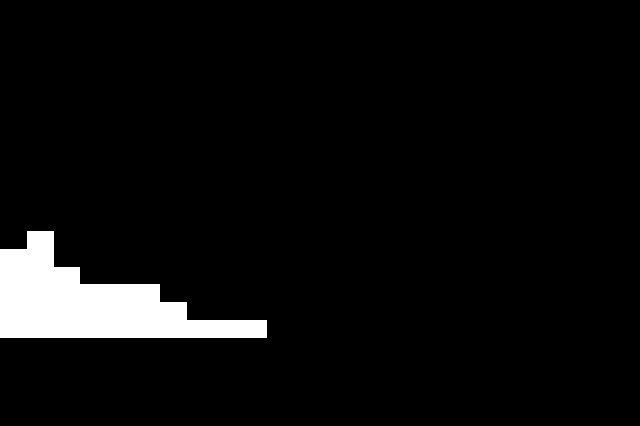

In [14]:
# Let's visualize the mask
pil_mask

## Utility: overlay the mask on the image

Defines `draw_mask`, a helper that blends the binary mask over the original image so you can quickly assess segmentation quality.

In [15]:
def draw_mask(mask: torch.Tensor, image: Image.Image) -> Image.Image:
    m = Image.fromarray(mask.to(torch.bool).numpy())
    red_mask = Image.new("RGBA", image.size, (255, 0, 0, 50))
    red_mask.putalpha(m)
    composite = Image.alpha_composite(image.convert("RGBA"), red_mask)
    return composite

## Overlay mask preview

Runs `draw_mask` and displays the result. This is the fastest way to sanity-check whether the referring expression picked the intended region.

In [16]:
gv_mask = draw_mask(mask, image)

## Prepare for bounding box extraction

The Granite mask is patch-based, but we can derive a bounding box by finding the tightest rectangle around foreground pixels in the full-resolution mask.

Next cells define helpers to compute and draw a bounding box.

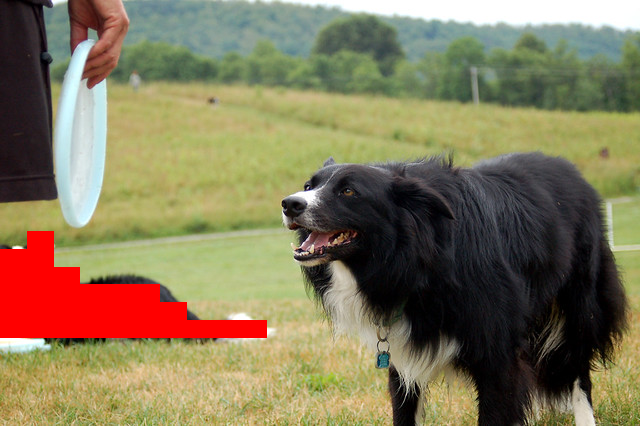

In [17]:
# Let's draw the mask on the image - as previously shown the mask is in the patch format. 
gv_mask 

## Utility: compute a bounding box from a mask

`mask_to_bbox` finds the tightest box around foreground pixels, optionally pads it, and can return:

- pixel coords: `xyxy`, `xywh`, `cxcywh`
- normalized coords: `*_norm`

If the mask is empty, it returns `None`.

In [18]:

from typing import Optional, Tuple

def mask_to_bbox(
    mask, 
    threshold: float = 0.5, 
    pad_ratio: float = 0.0, 
    image_size: Optional[Tuple[int, int]] = None,  # (W, H)
    return_format: str = "xyxy",  # "xyxy" | "xywh" | "cxcywh" | "xyxy_norm" | "xywh_norm" | "cxcywh_norm"
):
    """
    Derive a bounding box from a binary (or probabilistic) mask.

    Parameters
    ----------
    mask : torch.Tensor | np.ndarray
        Shape (H, W). Values 0/1 or probabilities [0,1].
    threshold : float
        Threshold to binarize if mask is probabilistic.
    pad_ratio : float
        Extra padding around the tight box, as a fraction of the box size (e.g., 0.05 = 5%).
    image_size : (W, H) or None
        If provided, clamp the padded box to these bounds, and enable *_norm outputs.
        If None, inferred from mask shape. For normalized formats, pass image_size.
    return_format : str
        Output format: 
        - pixel: "xyxy" (xmin, ymin, xmax, ymax), "xywh" (xmin, ymin, w, h), "cxcywh" (cx, cy, w, h)
        - normalized (0..1): "xyxy_norm", "xywh_norm", "cxcywh_norm"
    """
    import numpy as np

    # Convert to numpy (CPU)
    if isinstance(mask, torch.Tensor):
        mask_np = mask.detach().cpu().numpy()
    else:
        mask_np = mask

    # Validate dims
    if mask_np.ndim != 2:
        raise ValueError(f"mask must be 2D (H, W), got shape {mask_np.shape}")

    H, W = mask_np.shape
    if image_size is None:
        image_W, image_H = W, H
    else:
        image_W, image_H = image_size

    # Binarize if needed
    m = (mask_np > threshold).astype("uint8")

    # Handle empty mask (no positives)
    ys, xs = np.where(m > 0)
    if ys.size == 0 or xs.size == 0:
        # Return None to signal no box
        return None

    y_min = int(ys.min())
    y_max = int(ys.max())
    x_min = int(xs.min())
    x_max = int(xs.max())

    # Add padding (in pixels), proportional to box size
    box_w = x_max - x_min + 1
    box_h = y_max - y_min + 1
    if pad_ratio > 0:
        pad_x = int(round(box_w * pad_ratio))
        pad_y = int(round(box_h * pad_ratio))
        x_min -= pad_x
        x_max += pad_x
        y_min -= pad_y
        y_max += pad_y

    # Clamp to image
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(image_W - 1, x_max)
    y_max = min(image_H - 1, y_max)

    # Ensure valid after clamp
    if x_max < x_min or y_max < y_min:
        return None

    # Prepare output
    if return_format in ("xyxy", "xyxy_norm"):
        out = (float(x_min), float(y_min), float(x_max), float(y_max))
    elif return_format in ("xywh", "xywh_norm"):
        out = (float(x_min), float(y_min), float(x_max - x_min + 1), float(y_max - y_min + 1))
    elif return_format in ("cxcywh", "cxcywh_norm"):
        w = float(x_max - x_min + 1)
        h = float(y_max - y_min + 1)
        cx = float(x_min) + w / 2.0
        cy = float(y_min) + h / 2.0
        out = (cx, cy, w, h)
    else:
        raise ValueError(f"Unknown return_format: {return_format}")

    # Normalize if requested
    if return_format.endswith("_norm"):
        out = tuple([
            out[0] / image_W,
            out[1] / image_H,
            out[2] / image_W,
            out[3] / image_H,
        ])

    return out


## Utility: draw a bounding box on a PIL image

`draw_bbox_on_image` renders the computed bbox over the original image for a quick visual check.

In [19]:

from PIL import ImageDraw

def draw_bbox_on_image(
    image: Image.Image, 
    bbox, 
    fmt: str = "xyxy", 
    color=(0, 255, 0), 
    width: int = 3
) -> Image.Image:
    """
    Draw a bounding box on a PIL image.

    bbox : tuple
        One of the formats produced above. If normalized, set fmt to *_norm.
    fmt : "xyxy" | "xywh" | "cxcywh" | "xyxy_norm" | "xywh_norm" | "cxcywh_norm"
    """
    W, H = image.size

    def denorm(v, is_x=True):
        return v * (W if is_x else H)

    if fmt.endswith("_norm"):
        # denormalize to pixels
        if fmt.startswith("xyxy"):
            x1, y1, x2, y2 = bbox
            x1, y1 = denorm(x1, True), denorm(y1, False)
            x2, y2 = denorm(x2, True), denorm(y2, False)
            box_px = (x1, y1, x2, y2)
        elif fmt.startswith("xywh"):
            x, y, w, h = bbox
            x, y = denorm(x, True), denorm(y, False)
            w, h = denorm(w, True), denorm(h, False)
            box_px = (x, y, x + w - 1, y + h - 1)
        elif fmt.startswith("cxcywh"):
            cx, cy, w, h = bbox
            cx, cy = denorm(cx, True), denorm(cy, False)
            w, h = denorm(w, True), denorm(h, False)
            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2
            box_px = (x1, y1, x2, y2)
        else:
            raise ValueError(f"Unsupported fmt: {fmt}")
    else:
        # already in pixels
        if fmt == "xyxy":
            box_px = bbox
        elif fmt == "xywh":
            x, y, w, h = bbox
            box_px = (x, y, x + w - 1, y + h - 1)
        elif fmt == "cxcywh":
            cx, cy, w, h = bbox
            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2
            box_px = (x1, y1, x2, y2)
        else:
            raise ValueError(f"Unsupported fmt: {fmt}")

    img = image.copy().convert("RGBA")
    draw = ImageDraw.Draw(img)
    draw.rectangle(box_px, outline=color, width=width)
    return img


## Compute + draw the bounding box

This cell computes a bbox from the predicted mask and overlays it on the image.

If you get `None`, the mask had no foreground pixels (often due to a prompt mismatch or a failed `<seg>` parse).

bbox (xyxy): (0.0, 228.0, 274.0, 340.0)


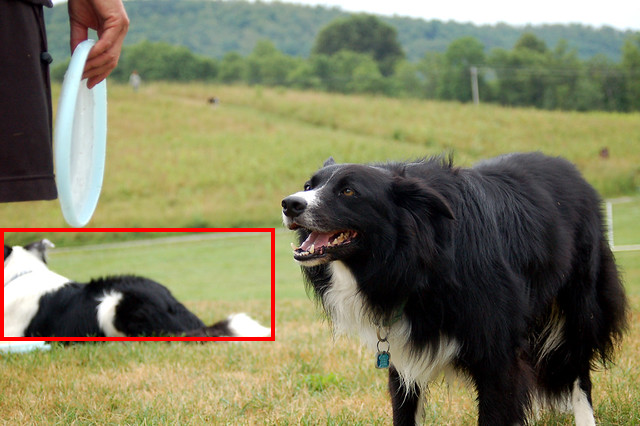

In [20]:
# 1) Build bbox from the full-res mask
bbox_xyxy = mask_to_bbox(
    mask, 
    threshold=0.5, 
    pad_ratio=0.03, 
    image_size=image.size, 
    return_format="xyxy"
)
print("bbox (xyxy):", bbox_xyxy)

# 2) Draw it
if bbox_xyxy is not None:
    boxed = draw_bbox_on_image(image, bbox_xyxy, fmt="xyxy", color=(255, 0, 0), width=4)
    display(boxed)
else:
    print("No foreground pixels; cannot compute bbox.")


## Next steps

(Optional)

- Try different referring expressions.
- Try padding/cropping your input images to a square (see notes at the top) for more consistent alignment.
- Save outputs: `image.save(...)`, `pil_mask.save(...)`, etc.

In [ ]:
# (Optional) Add your own experiments below.
